In [2]:
with open("../scenario-a-zip-duration.txt") as f:
    it = 0
    lines = []
    while(line := f.readline()):
        it+=1
        lines.append(line)
        f.readline()
    print(it)

30


In [3]:
import re
durations = [m.group(1) for m in [re.search(r'Duration:\s*([\d.]+)\s*ms', line) for line in lines] if m]
durations = [float(dur) for dur in durations]
durations

[97.41,
 70.47,
 71.28,
 71.75,
 86.79,
 86.72,
 86.5,
 86.35,
 78.53,
 83.03,
 82.52,
 78.21,
 78.25,
 78.46,
 72.78,
 71.72,
 66.99,
 71.48,
 86.6,
 86.88,
 87.16,
 70.39,
 89.05,
 66.6,
 82.67,
 79.53,
 82.48,
 78.36,
 78.42,
 75.38]

In [4]:
init_durations = [m.group(1) for m in [re.search(r'Init Duration:\s*([\d.]+)\s*ms', line) for line in lines] if m]
init_durations = [float(dur) for dur in init_durations]
init_durations

[618.14]

In [5]:
import numpy as np
cold_duration = durations[0]
warm_duration= np.mean(durations[1:])
init_duration = init_durations[0]


In [6]:
warm_duration

np.float64(78.8051724137931)

In [7]:
with open("../scenario-a-container-duration.txt") as f:
    it = 0
    lines = []
    while(line := f.readline()):
        it+=1
        lines.append(line)
        f.readline()
    print(it)

30


In [8]:
import re
container_durations = [m.group(1) for m in [re.search(r'Duration:\s*([\d.]+)\s*ms', line) for line in lines] if m]
container_durations = [float(dur) for dur in container_durations]
container_init_durations = [m.group(1) for m in [re.search(r'Init Duration:\s*([\d.]+)\s*ms', line) for line in lines] if m]
container_init_durations = [float(dur) for dur in container_init_durations]
container_cold_duration = container_durations[0]
container_warm_duration= np.mean(container_durations[1:])
container_init_duration = container_init_durations[0]

In [9]:
# From OHA report:
# Container
# Slowest:	1.0221 sec
# Fastest:	0.0844 sec
# Average:	0.1332 sec
# ZIP
#   Slowest:	1.2014 sec
#   Fastest:	0.0850 sec
#   Average:	0.1425 sec
client_cold_latency_zip = 1201.4
client_warm_latency_zip = 85.0
client_cold_latency_container = 1022.1
client_warm_latency_container = 84.4
RTTI_zip_cold = client_cold_latency_zip - cold_duration - init_duration
RTTI_zip_warm = client_warm_latency_zip - warm_duration
RTTI_container_cold = client_cold_latency_container - container_cold_duration - container_init_duration
RTTI_container_warm = client_warm_latency_container - container_warm_duration
RTTI_zip_cold, RTTI_zip_warm, RTTI_container_cold, RTTI_container_warm

(485.85, np.float64(6.194827586206898), 313.75, np.float64(6.934482758620717))

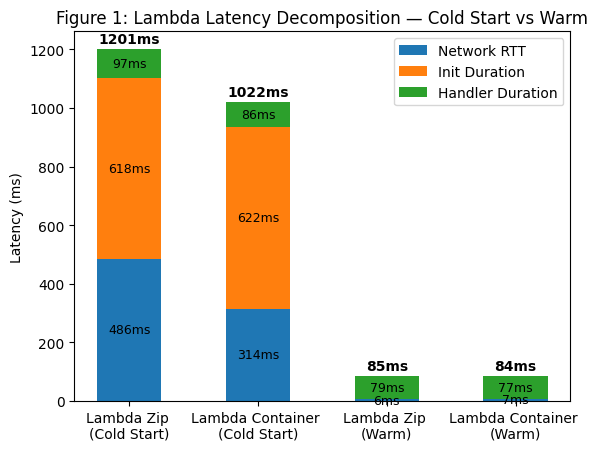

In [10]:
import matplotlib.pyplot as plt

workspaces = (
    "Lambda Zip \n(Cold Start)",
    "Lambda Container \n(Cold Start)",
    "Lambda Zip \n(Warm)",
    "Lambda Container \n(Warm)",
)

weight_counts = {
    "FirstLevel": np.array([70, 31, 58]),
    "SecondLevel": np.array([82, 37, 66]),
}
width = 0.5

init = [init_duration, container_init_duration, 0, 0]
handler = [cold_duration, container_cold_duration, warm_duration, container_warm_duration]
rtti = [RTTI_zip_cold, RTTI_container_cold, RTTI_zip_warm, RTTI_container_warm]

x = np.arange(4)
width = 0.5

fig, ax = plt.subplots()
p0 = ax.bar(x, rtti, width, label='Network RTT')
p1 = ax.bar(x, init, width, bottom=rtti, label='Init Duration')
p2 = ax.bar(x, handler, width, bottom=np.array(rtti) + np.array(init), label='Handler Duration')

# Add labels for each segment
ax.bar_label(p0, labels=[f"{v:.0f}ms" if v > 0 else "" for v in rtti], label_type='center', fontsize=9)
ax.bar_label(p1, labels=[f"{v:.0f}ms" if v > 0 else "" for v in init], label_type='center', fontsize=9)
ax.bar_label(p2, labels=[f"{v:.0f}ms" for v in handler], label_type='center', fontsize=9)

# Add total latency at the top of each bar
for i, (rtti_v, init_v, handler_v) in enumerate(zip(rtti, init, handler)):
    total = rtti_v + init_v + handler_v
    ax.text(i, total + 10, f"{total:.0f}ms", ha='center', va='bottom', fontsize=10, fontweight='bold')


ax.set_ylabel('Latency (ms)')
ax.set_title('Figure 1: Lambda Latency Decomposition — Cold Start vs Warm')
ax.set_xticks(x)
ax.set_xticklabels(workspaces)
ax.legend()
plt.show()

# Assignment 6: Cost vs RPS Analysis

Calculate monthly costs for Lambda, Fargate, and EC2 across different RPS levels and identify the break-even point.

In [ ]:
LAMBDA_HANDLER_DURATION = 0.09258
LAMBDA_MEMORY_GB = 0.5 
SECONDS_PER_MONTH = 30 * 24 * 3600 
LAMBDA_REQUEST_PRICE = 0.20 / 1_000_000
LAMBDA_COMPUTE_PRICE = 0.0000166667  
FARGATE_MONTHLY_COST = 5.89  
EC2_MONTHLY_COST = 7.49  

def lambda_cost(rps):
    """Calculate monthly Lambda cost for given average RPS"""
    requests_per_month = rps * SECONDS_PER_MONTH
    request_cost = requests_per_month * LAMBDA_REQUEST_PRICE
    gb_seconds = requests_per_month * LAMBDA_HANDLER_DURATION * LAMBDA_MEMORY_GB
    compute_cost = gb_seconds * LAMBDA_COMPUTE_PRICE
    return request_cost + compute_cost

rps_range = np.linspace(0, 15, 100)
lambda_costs = [lambda_cost(rps) for rps in rps_range]

breakeven_rps = FARGATE_MONTHLY_COST / (lambda_cost(1) * 1) 
for rps in rps_range:
    if lambda_cost(rps) >= FARGATE_MONTHLY_COST:
        breakeven_rps = rps
        break

print(f"Breakeven RPS (Lambda vs Fargate): {breakeven_rps:.2f} RPS")
print(f"Lambda cost at breakeven: ${lambda_cost(breakeven_rps):.2f}")
print(f"Fargate cost: ${FARGATE_MONTHLY_COST:.2f}")
print(f"EC2 cost: ${EC2_MONTHLY_COST:.2f}")

Breakeven RPS (Lambda vs Fargate): 2.42 RPS
Lambda cost at breakeven: $6.10
Fargate cost: $5.89
EC2 cost: $7.49


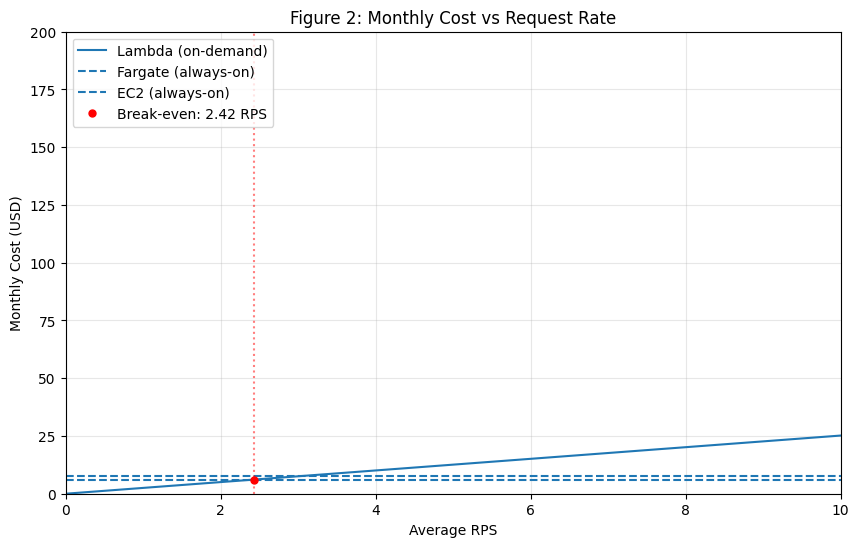

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rps_range, lambda_costs,  label='Lambda (on-demand)', marker='')
ax.axhline(y=FARGATE_MONTHLY_COST, label='Fargate (always-on)',linestyle='--')
ax.axhline(y=EC2_MONTHLY_COST,  label='EC2 (always-on)', linestyle='--')
ax.plot(breakeven_rps, FARGATE_MONTHLY_COST, 'ro', markersize=5, label=f'Break-even: {breakeven_rps:.2f} RPS', zorder=5)
ax.axvline(x=breakeven_rps, color='red', linestyle=':', alpha=0.5)

ax.set_xlabel('Average RPS')
ax.set_ylabel('Monthly Cost (USD)')
ax.set_title('Figure 2: Monthly Cost vs Request Rate')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(0, 200)
plt.show()